In [1]:
import matplotlib.pyplot as plt

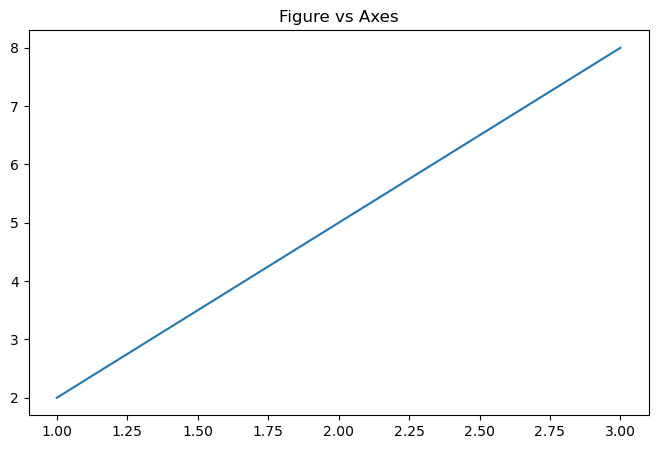

In [2]:
fig , ax = plt.subplots(figsize=(8,5))

ax.plot([1,2,3],[2,5,8])
ax.set_title("Figure vs Axes")
plt.show()

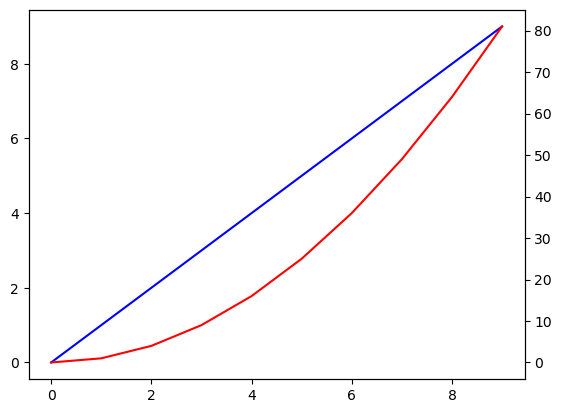

In [3]:
import numpy as np

x =  np.arange(10)
y1 = x
y2 = x**2

fig, ax1 = plt.subplots()

ax1.plot(x , y1, color ="blue")

ax2= ax1.twinx()
ax2.plot(x , y2, color="red")

plt.show()


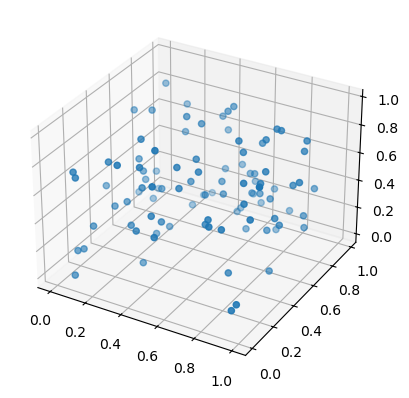

In [4]:
#3d plot
from mpl_toolkits.mplot3d import Axes3D

fig= plt.figure()

ax = fig.add_subplot(111,projection="3d")

x = np.random.rand(100)
y =np.random.rand(100)
z = np.random.rand(100)

ax.scatter(x,y,z)

plt.show()

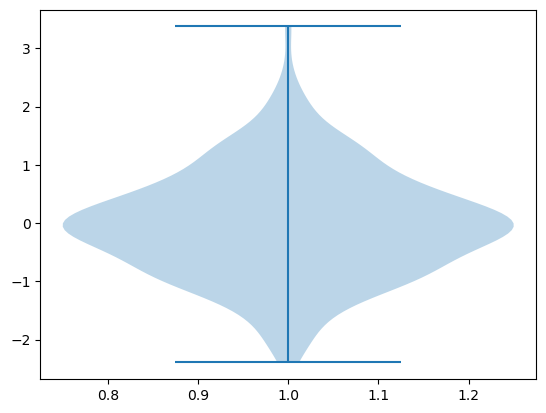

In [5]:
#violin plot
data = np.random.randn(200)

plt.violinplot(data)
plt.show()

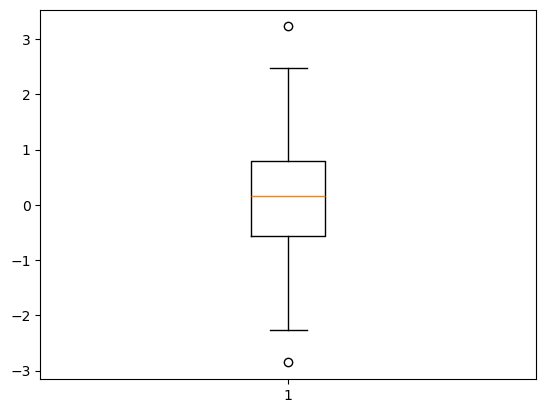

In [6]:
#box plot
data = np.random.randn(200)

plt.boxplot(data)
plt.show()

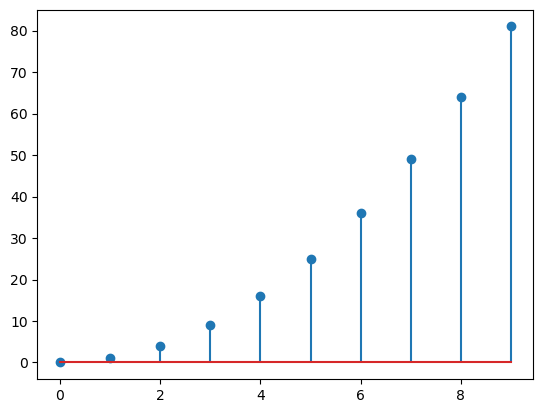

In [7]:
#stem plot
x = np.arange(10)

y = x**2
plt.stem(x,y)
plt.show()

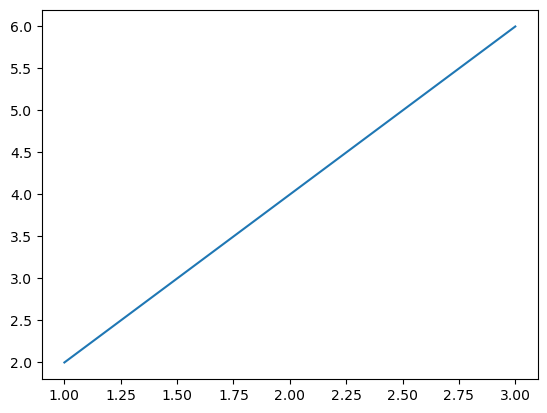

In [8]:
#saving features
plt.plot([1,2,3],[2,4,6])

plt.savefig("plot.png",
            dpi = 300,
            bbox_inches ="tight")

In [9]:
!pip install spacepy

In [10]:
!pip install tensorflow

In [20]:
import os
import numpy as np
import pandas as pd
from spacepy import pycdf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [21]:
# 1️⃣ DATA INGESTION & PREPROCESSING
def read_cdf_files(folder_path):
    data_frames = []
    for file in os.listdir(folder_path):
        if file.endswith(".cdf"):
            cdf = pycdf.CDF(os.path.join(folder_path, file))
            df = pd.DataFrame(cdf)
            data_frames.append(df)
    return pd.concat(data_frames, ignore_index=True)

def preprocess_data(df):
    df = df.fillna(method='ffill')  # Handle missing values
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').resample('30T').mean()  # Time synchronization
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    return scaled, scaler

In [22]:
# 2️⃣ MODEL LAYER (LSTM)
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [23]:
# 3️⃣ MULTI-HORIZON FORECASTING
def forecast(model, data, horizons=[1, 12, 24]):
    predictions = {}
    for h in horizons:
        pred = model.predict(data[-h:])
        predictions[f"{h*30}min_ahead"] = pred[-1][0]
    return predictions

In [24]:
# 4️⃣ OUTPUT GENERATION & ANALYTICS
def categorize_risk(value, thresholds=(0.3, 0.7)):
    if value < thresholds[0]:
        return "Low"
    elif value < thresholds[1]:
        return "Medium"
    else:
        return "High"

In [25]:
# 5️⃣ VISUALIZATION DASHBOARD
def visualize_forecast(predictions):
    plt.figure(figsize=(8, 4))
    plt.bar(predictions.keys(), predictions.values(), color='skyblue')
    plt.title("Electron Flux Forecast (Multi-Horizon)")
    plt.xlabel("Forecast Horizon")
    plt.ylabel("Predicted Flux Value")
    plt.show()


In [26]:
# 🚀 MAIN EXECUTION
if __name__ == "__main__":
    folder = "data/cdf_files"
    raw_data = read_cdf_files(folder)
    processed_data, scaler = preprocess_data(raw_data)

    X = []
    y = []
    window = 24
    for i in range(len(processed_data) - window):
        X.append(processed_data[i:i+window])
        y.append(processed_data[i+window])
    X, y = np.array(X), np.array(y)

    model = build_lstm_model((X.shape[1], X.shape[2]))
    model.fit(X, y, epochs=10, batch_size=16, validation_split=0.2)

    predictions = forecast(model, X)
    visualize_forecast(predictions)

    for horizon, value in predictions.items():
        risk = categorize_risk(value)
        print(f"{horizon}: {value:.4f} → Risk Level: {risk}")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/cdf_files'